In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import os
import shutil
import tarfile
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.layers import Dropout, Lambda
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall, MeanIoU

%matplotlib inline
%load_ext tensorboard

from sklearn.datasets import *

## Mount Google Drive to access preprocessed datasets

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Check if a GPU is available for TensorFlow training

In [4]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"SUCCESS: {len(gpus)} GPU(s) detected!")
    print(f"Device Name: {gpus[0].name}")
else:
    print(" ERROR: No GPU detected. You are running on CPU.")

SUCCESS: 1 GPU(s) detected!
Device Name: /physical_device:GPU:0


## Extract the preprocessed dataset from the ZIP file into the working directory

In [5]:
import zipfile
import os

# Path to the ZIP file containing the preprocessed dataset
zip_path = "/content/drive/MyDrive/segmentatioImage/processed_unet.zip"

# Directory where the dataset will be extracted
base_path = "/content/processed_unet"

# Create the destination folder if it does not exist
os.makedirs(base_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_path)

print("Dataset extracted successfully")

Dataset extracted successfully


## Display the files and folders extracted in the dataset directory

In [6]:
print(os.listdir(base_path))

['images', 'masks']


In [7]:
IMAGES_DIR = os.path.join("/content/processed_unet/images")
MASKS_DIR = os.path.join("/content/processed_unet/masks")


## Prepare and split the dataset into training, validation, and test sets based on patient IDs

In [8]:
# Split the dataset into training, validation, and test sets based on patient IDs
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
import os
import numpy as np

# =========================
# 1. List image and mask files
# =========================

images_list = sorted(os.listdir(IMAGES_DIR))
masks_list = sorted(os.listdir(MASKS_DIR))

# Extract unique patient IDs
patient_ids = sorted(list(set([
    "_".join(img.split("_")[:2])
    for img in images_list
])))

print("Total patients:", len(patient_ids))


# =========================
# 2. Split patients into train, validation, and test sets
# =========================

train_patients, temp_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,
    random_state=42
)

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))


# =========================
# 3. Create image and mask lists for each split
# =========================

train_images, train_masks = [], []
val_images, val_masks = [], []
test_images, test_masks = [], []

for img_name, mask_name in zip(images_list, masks_list):

    patient_id = "_".join(img_name.split("_")[:2])

    if patient_id in train_patients:
        train_images.append(img_name)
        train_masks.append(mask_name)

    elif patient_id in val_patients:
        val_images.append(img_name)
        val_masks.append(mask_name)

    elif patient_id in test_patients:
        test_images.append(img_name)
        test_masks.append(mask_name)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Total patients: 800
Train patients: 640
Validation patients: 80
Test patients: 80
Train images: 37553
Validation images: 4799
Test images: 4715


## Count the total number of images and segmentation masks in the dataset

In [9]:
num_images = len(os.listdir(IMAGES_DIR))
num_masks = len(os.listdir(MASKS_DIR))

print(f"Cantidad de imágenes: {num_images}")
print(f"Cantidad de máscaras: {num_masks}")

Cantidad de imágenes: 47067
Cantidad de máscaras: 47067


## Custom data generator for loading and preprocessing brain tumor MRI images and segmentation masks in batches

In [10]:
class BrainTumorGenerator(Sequence):

    def __init__(
        self,
        image_files,
        mask_files,
        images_dir,
        masks_dir,
        batch_size=16,
        shuffle=True
    ):
        self.image_files = image_files
        self.mask_files = mask_files
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indexes = np.arange(len(self.image_files))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_files) / self.batch_size))

    def __getitem__(self, index):

        batch_indexes = self.indexes[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        batch_images = []
        batch_masks = []

        for i in batch_indexes:

            img = np.load(
                os.path.join(self.images_dir, self.image_files[i])
            )

            mask = np.load(
                os.path.join(self.masks_dir, self.mask_files[i])
            )

            # images
            img = img.astype(np.float32) / 255.0

            # multiclass mask
            mask = mask.astype(np.uint8)
            mask[mask == 4] = 3

            # add chanel to the mask
            mask = np.expand_dims(mask, axis=-1)

            batch_images.append(img)
            batch_masks.append(mask)

        X = np.array(batch_images, dtype=np.float32)
        y = np.array(batch_masks, dtype=np.uint8)

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Create data generators for training, validation, and testing datasets

In [23]:
final_train_generator = BrainTumorGenerator(
    train_images,
    train_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=True
)

final_val_generator = BrainTumorGenerator(
    val_images,
    val_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=False
)

test_generator = BrainTumorGenerator(
    test_images,
    test_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=False
)

# Define Dice coefficient metric and Dice loss function for multi-class image segmentation

In [24]:
@tf.keras.utils.register_keras_serializable()
def dice_coef(y_true, y_pred, smooth=1e-7):
    '''
    Dice coefficient for 10 categories. Ignores background pixel label 0
    Pass to model as metric during compile statement
    '''
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=4)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    return K.mean((2. * intersect / (denom + smooth)))

@tf.keras.utils.register_keras_serializable()
def dice_coef_loss(y_true, y_pred):
    '''
    Dice loss to minimize. Pass to model as loss during compile statement
    '''
    return 1 - dice_coef(y_true, y_pred)

In [25]:
@tf.keras.utils.register_keras_serializable()
def mean_iou(y_true, y_pred, smooth=1e-7):

    # Convert predictions from probabilities to labels
    y_pred = tf.argmax(y_pred, axis=-1)

    # Remove last dimension from ground truth
    y_true = tf.squeeze(y_true, axis=-1)

    # Convert to int32
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.cast(y_pred, tf.int32)

    iou_scores = []

    # Ignore background class (0)
    for class_id in range(1, 4):

        true_class = tf.equal(y_true, class_id)
        pred_class = tf.equal(y_pred, class_id)

        intersection = tf.reduce_sum(
            tf.cast(true_class & pred_class, tf.float32)
        )

        union = tf.reduce_sum(
            tf.cast(true_class | pred_class, tf.float32)
        )

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou)

    return tf.reduce_mean(iou_scores)

# Define the U-Net model architecture

In [26]:
def get_model_UNET(kernels,IMG_HEIGHT=128, IMG_WIDTH=128, IMG_CHANNELS=4, N_CLASSES=4):

    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

    c1 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)


    c5 = Conv2D(kernels*16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(kernels*16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c5)

    u6 = Conv2DTranspose(kernels*8, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])


    c6 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(kernels*4, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(kernels*2, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(kernels, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(N_CLASSES, (1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])

    model.compile(
        optimizer='adam',
        loss= dice_coef_loss,
        metrics=[dice_coef,mean_iou]
    )

    return model

In [16]:
model = get_model_UNET(kernels=16)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        592 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 128) │          0 │ conv2d_7[0][0]  

 Total params: 1,941,300 (7.41 MB)

 Trainable params: 1,941,300 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

## Cross Valitation

In [17]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=2,shuffle=True,random_state=42)

filter_options = [16,32]


best_mean_dice = -1

best_filters = None

for filters in filter_options:

    fold_no = 1

    train_dice_scores,train_Iou_scores,val_dice_scores = [],[],[]
    val_Iou_scores,train_loss,val_loss = [],[],[]


    for train_idx, val_idx in kf.split(train_patients):

        print(f"\n========== FOLD {fold_no} ==========")

        # ======================================
        # PATIENT SPLIT
        # ======================================

        fold_train_patients = [train_patients[i] for i in train_idx]

        fold_val_patients = [train_patients[i] for i in val_idx]

        # ======================================
        # IMAGE/MASK LISTS
        # ======================================

        fold_train_images = []
        fold_train_masks = []

        fold_val_images = []
        fold_val_masks = []

        for img_name, mask_name in zip(images_list,masks_list):

            patient_id = "_".join(img_name.split("_")[:2])

            if patient_id in fold_train_patients:

                fold_train_images.append(img_name)
                fold_train_masks.append(mask_name)

            elif patient_id in fold_val_patients:

                fold_val_images.append(img_name)
                fold_val_masks.append(mask_name)


        fold_train_generator = BrainTumorGenerator(
            fold_train_images,
            fold_train_masks,
            IMAGES_DIR,
            MASKS_DIR,
            batch_size=16,
            shuffle=True
        )

        fold_val_generator = BrainTumorGenerator(
            fold_val_images,
            fold_val_masks,
            IMAGES_DIR,
            MASKS_DIR,
            batch_size=16,
            shuffle=False
        )

        # ======================================
        # MODEL
        # ======================================

        model = get_model_UNET(filters)


        # ======================================
        # CALLBACKS
        # ======================================

        earlystopper = EarlyStopping(
            monitor='val_dice_coef',
            mode='max',
            patience=5,
            verbose=1,
            restore_best_weights=True)


        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1)

        # ======================================
        # TRAIN
        # ======================================

        history = model.fit(
            fold_train_generator,
            validation_data=fold_val_generator,
            epochs=4,
            callbacks=[
                earlystopper,
                reduce_lr
            ]
        )

        # ======================================
        # EVALUATE
        # ======================================

        scores_train = model.evaluate(fold_train_generator )
        scores_val = model.evaluate(fold_val_generator)

        train_loss.append(scores_train[0])
        train_dice_scores.append(scores_train[1])
        current_dice = scores_val[1]
        train_Iou_scores.append(scores_train[2])

        val_loss.append(scores_val[0])
        val_dice_scores.append(scores_val[1])
        val_Iou_scores.append(scores_val[2])


        fold_no += 1

    mean_dice = np.mean(val_dice_scores)

    if mean_dice > best_mean_dice:
      best_mean_dice = mean_dice
      best_filters = filters



========== FOLD 1 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 112s 73ms/step - dice_coef: 0.4839 - loss: 0.5163 - mean_iou: 0.1991 - val_dice_coef: 0.6201 - val_loss: 0.3799 - val_mean_iou: 0.4037 - learning_rate: 0.0010
Epoch 2/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 61s 52ms/step - dice_coef: 0.7446 - loss: 0.2552 - mean_iou: 0.5736 - val_dice_coef: 0.7398 - val_loss: 0.2601 - val_mean_iou: 0.5480 - learning_rate: 0.0010
Epoch 3/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 62s 52ms/step - dice_coef: 0.8041 - loss: 0.1960 - mean_iou: 0.6641 - val_dice_coef: 0.7582 - val_loss: 0.2418 - val_mean_iou: 0.5775 - learning_rate: 0.0010
Epoch 4/4
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 63s 53ms/step - dice_coef: 0.8277 - loss: 0.1724 - mean_iou: 0.7000 - val_dice_coef: 0.7628 - val_loss: 0.2372 - val_mean_iou: 0.5900 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - dice_coef: 0.8422 - loss: 0.1578 - mean_iou: 0.7207
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step 

In [27]:
print(best_filters)

16


# Define training callbacks for early stopping, model checkpointing, learning rate reduction, and training logging

In [28]:
earlystopper = EarlyStopping(
    monitor='val_dice_coef',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

checkpointer = ModelCheckpoint(
    'model-best.keras',
    verbose=1,
    save_best_only=True,
    monitor='val_dice_coef',
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

csv_logger = CSVLogger('training_log.csv')

# Train the U-Net model using the training and validation generators

In [29]:
model = get_model_UNET(best_filters)

modeltrain = model.fit(
    final_train_generator,
    validation_data=final_val_generator,
    epochs=30,
    callbacks=[
        earlystopper,
        checkpointer,
        reduce_lr
    ]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2348/2348 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coef: 0.4463 - loss: 0.5537 - mean_iou: 0.1430
Epoch 1: val_dice_coef improved from None to 0.72530, saving model to model-best.keras

Epoch 1: finished saving model to model-best.keras
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 129s 47ms/step - dice_coef: 0.5414 - loss: 0.4586 - mean_iou: 0.2242 - val_dice_coef: 0.7253 - val_loss: 0.2747 - val_mean_iou: 0.5089 - learning_rate: 0.0010
Epoch 2/30
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - dice_coef: 0.7662 - loss: 0.2338 - mean_iou: 0.5991
Epoch 2: val_dice_coef improved from 0.72530 to 0.78275, saving model to model-best.keras

Epoch 2: finished saving model to model-best.keras
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 97s 41ms/step - dice_coef: 0.7847 - loss: 0.2153 - mean_iou: 0.6287 - val_dice_coef: 0.7828 - val_loss: 0.2173 - val_mean_iou: 0.6255 - learning_rate: 0.0010
Epoch 3/30
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - dice_coef: 0.8134 - loss: 0.1867 - mean_iou: 0.6732
Epoch 3: val_dice_coef i

# Evaluate the trained model on the test dataset and display performance metrics

In [30]:
best_epoch = np.argmax(modeltrain.history['val_dice_coef'])

print(f"Best Epoch: {best_epoch + 1}")

print(f"Train Loss: {modeltrain.history['loss'][best_epoch]:.4f}")
print(f"Validation Loss: {modeltrain.history['val_loss'][best_epoch]:.4f}")

print(f"Train Dice: {modeltrain.history['dice_coef'][best_epoch]:.4f}")
print(f"Validation Dice: {modeltrain.history['val_dice_coef'][best_epoch]:.4f}")

Best Epoch: 21
Train Loss: 0.1215
Validation Loss: 0.1682
Train Dice: 0.8785
Validation Dice: 0.8318


# Load the best saved model and evaluate its performance on the test dataset


In [31]:
best_model = load_model(
    'model-best.keras',
    custom_objects={
        'dice_coef': dice_coef
    }
)

In [32]:
resultstest = best_model.evaluate(test_generator)

for name, value in zip(best_model.metrics_names, resultstest ):
    print(f"{name}: {value:.4f}")

295/295 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - dice_coef: 0.8225 - loss: 0.1776 - mean_iou: 0.6789
loss: 0.1776
compile_metrics: 0.8225


# Compute multi-class Dice scores and visualize MRI slices with ground truth and predicted tumor segmentations

In [34]:
def multiclass_dice_score(y_true, y_pred, num_classes=4, smooth=1e-6, include_background=True):
    dice_scores = []

    start_class = 0 if include_background else 1

    for class_id in range(start_class, num_classes):
        y_true_class = (y_true == class_id).astype(np.uint8)
        y_pred_class = (y_pred == class_id).astype(np.uint8)

        intersection = np.sum(y_true_class * y_pred_class)

        dice = (2.0 * intersection + smooth) / (
            np.sum(y_true_class) + np.sum(y_pred_class) + smooth
        )

        dice_scores.append(dice)

    return np.mean(dice_scores), dice_scores


def visualize_slice_80(model, patient_id, slice_num):
    image_name = f"{patient_id}_slice_{slice_num}.npy"

    img = np.load(os.path.join(IMAGES_DIR, image_name))
    img_input = img.astype(np.float32) / 255.0

    true_mask = np.load(os.path.join(MASKS_DIR, image_name)).astype(np.uint8)
    true_mask[true_mask == 4] = 3

    pred_mask = model.predict(
        np.expand_dims(img_input, axis=0),
        verbose=0
    )[0]

    pred_classes = np.argmax(pred_mask, axis=-1).astype(np.uint8)

    dice_mean, dice_per_class = multiclass_dice_score(
        true_mask,
        pred_classes,
        num_classes=4,
        include_background=False
    )

    print("True mask classes:", np.unique(true_mask))
    print("Predicted classes:", np.unique(pred_classes))

    print("Pixels clase 3 reales:",
          np.sum(true_mask == 3))

    print("Pixels clase 3 predichos:",
      np.sum(pred_classes == 3))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img[:, :, 0], cmap="gray")
    axes[0].imshow(true_mask, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[0].set_title("Overlay Original")
    axes[0].axis("off")

    axes[1].imshow(true_mask, cmap="jet", vmin=0, vmax=4)
    axes[1].set_title("Original Segmentation")
    axes[1].axis("off")

    axes[2].imshow(pred_classes, cmap="jet", vmin=0, vmax=4)
    axes[2].set_title("Predicted Segmentation")
    axes[2].axis("off")

    axes[3].imshow(img[:, :, 0], cmap="gray")
    axes[3].imshow(pred_classes, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[3].set_title(f"Overlay Prediction\nMean Dice: {dice_mean:.4f}")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Mean Multiclass Dice: {dice_mean:.4f}")
    print(f"Dice clase 0: {dice_per_class[0]:.4f}")
    print(f"Dice clase 1: {dice_per_class[1]:.4f}")
    print(f"Dice clase 2: {dice_per_class[2]:.4f}")
    #print(f"Dice clase 3: {dice_per_class[3]:.4f}")



True mask classes: [0 1 2 3]
Predicted classes: [0 1 2 3]
Pixels clase 3 reales: 140
Pixels clase 3 predichos: 145


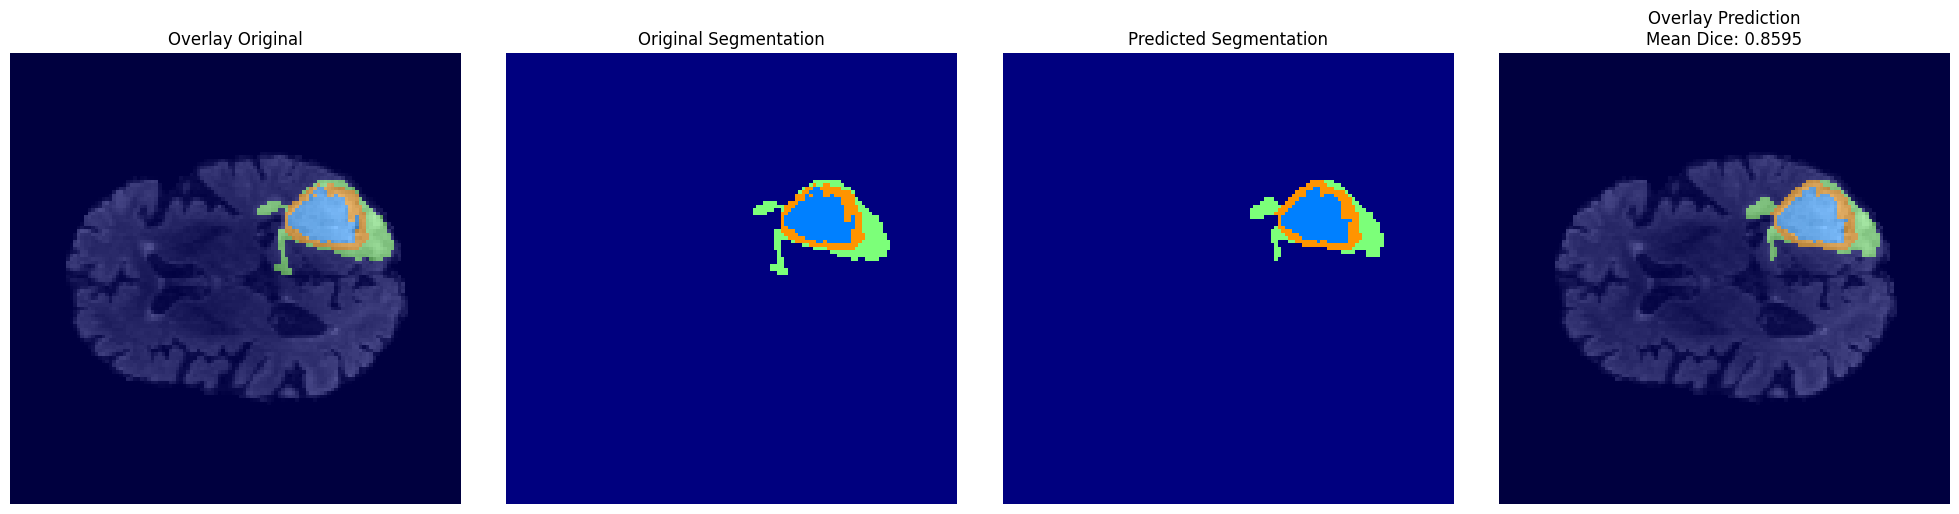

Mean Multiclass Dice: 0.8595
Dice clase 0: 0.9612
Dice clase 1: 0.7472
Dice clase 2: 0.8702


In [35]:
visualize_slice_80(model, "BraTS2021_00020",70)